# Detección de Fraude en Transacciones con Tarjeta de Crédito

## Contexto
Dataset de transacciones reales de tarjetas de crédito europeas (septiembre 2013).
284,807 transacciones, de las cuales solo 492 son fraude (0.17%).

## Objetivo
Construir un modelo capaz de identificar transacciones fraudulentas en un dataset
severamente desbalanceado, aplicando análisis estadístico y regresión logística.

## Stack
- Python (pandas, numpy, scikit-learn, scipy, seaborn)
- SQL (SQLite)

## Estructura del análisis
1. Limpieza y preparación de datos
2. Análisis exploratorio + estadística
3. Modelo predictivo
4. Consultas SQL

## 0. Carga de datos y librerías

In [1]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sqlite3
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             average_precision_score, PrecisionRecallDisplay)

import os
archivo = os.path.join(path, 'creditcard.csv')
df = pd.read_csv(archivo)

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Limpieza y preparación de datos
Verificamos calidad del dataset: nulos, duplicados y escalado de variables.
`Amount` y `Time` no pasaron por PCA — las escalamos para igualarlas al rango de V1-V28.

In [3]:
# Verificar nulos
print("Valores nulos por columna:")
print(df.isnull().sum().sum())

# Verificar duplicados
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

Valores nulos por columna:
0

Filas duplicadas: 1081


### Duplicados
Se encontraron 1,081 filas duplicadas. Dado que las variables son componentes
principales, la probabilidad de duplicación exacta por coincidencia es despreciable,
se asume error de registro y se eliminan.

In [4]:
df = df.drop_duplicates()
print(f"Shape después de eliminar duplicados: {df.shape}")

Shape después de eliminar duplicados: (283726, 31)


### Estandarización de variables
`Amount` y `Time` no pasaron por PCA — están en su escala original.
Las estandarizamos (media 0, desviación estándar 1) para igualarlas
al rango de V1-V28 y evitar que dominen el modelo.
Usamos StandardScaler en lugar de MinMaxScaler porque este último
es sensible a outliers, frecuentes en datasets de fraude.

In [5]:
scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df.head(1)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_scaled,Time_scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.2442,-1.996823


### Verificación final del dataset limpio

In [6]:
print(f"Shape final: {df.shape}")
print(f"Valores nulos: {df.isnull().sum().sum()}")
print(f"Distribución de clases:")
print(df['Class'].value_counts())
print(f"\nFraudes: {df['Class'].sum()} ({df['Class'].mean()*100:.3f}%)")

Shape final: (283726, 33)
Valores nulos: 0
Distribución de clases:
Class
0    283253
1       473
Name: count, dtype: int64

Fraudes: 473 (0.167%)


### Resumen bloque de limpieza
- Shape original: (284,807 × 31) → Shape final: (283,726 × 31)
- Valores nulos: 0
- Duplicados eliminados: 1,081 (19 correspondían a transacciones fraudulentas)
- Variables estandarizadas: `Amount` y `Time`
- Fraudes restantes: 473 (0.167% del total)

In [7]:
print(df[df['Class']==1]['Amount'].describe())

count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [8]:
monto_riesgo = df[df['Class']==1]['Amount'].sum()
print(f"Monto total en riesgo: €{monto_riesgo:,.2f}")

Monto total en riesgo: €58,591.39


## 2. Análisis Exploratorio y Estadística
Exploramos la distribución de las variables, comparamos el comportamiento
entre transacciones legítimas y fraudulentas, y aplicamos pruebas estadísticas
para validar las diferencias observadas.

### 2.1 Distribución del monto por clase
¿Los montos de las transacciones fraudulentas siguen un patrón distinto
al de las legítimas?

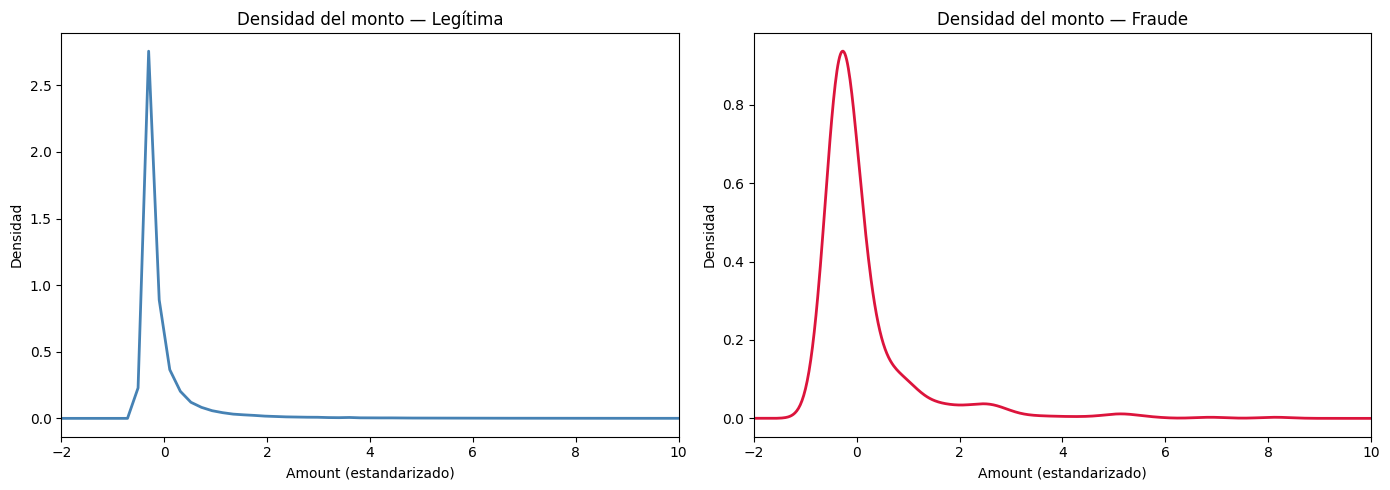

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (clase, label, color) in enumerate(zip([0, 1], ['Legítima', 'Fraude'], ['steelblue', 'crimson'])):
    subset = df[df['Class'] == clase]['Amount_scaled']
    subset.plot.kde(ax=axes[i], color=color, linewidth=2)
    axes[i].set_title(f'Densidad del monto — {label}')
    axes[i].set_xlabel('Amount (estandarizado)')
    axes[i].set_ylabel('Densidad')
    axes[i].set_xlim(-2, 10)

plt.tight_layout()
plt.show()

#### 2.1 Distribución del monto por clase

Las curvas de densidad muestran cómo se distribuyen los montos
estandarizados en cada clase:

- **Legítima:** distribución altamente concentrada cerca del promedio
(pico de densidad ~2.5), con caída rápida y cola derecha larga y delgada.
Las transacciones legítimas tienden a montos muy similares entre sí.

- **Fraude:** distribución más dispersa (pico de densidad ~0.9),
con base más ancha (entre -1 y 1) y caída más suave.
Presenta pequeñas ondulaciones en la cola derecha,
sugiriendo concentraciones de fraude en montos específicos más altos.

**Hallazgo:** el monto no discrimina perfectamente entre clases,
pero el fraude muestra mayor dispersión y patrones en montos específicos,
lo que lo convierte en una variable de apoyo para el modelo.

### 2.2 Detección de valores atípicos — Regla de 3σ
Una transacción es atípica si su monto se aleja más de 3 desviaciones
estándar de la media. En una distribución normal el 99.7% de los datos
cae dentro de ese rango, lo que está fuera es estadísticamente inusual.

In [10]:
media = df['Amount_scaled'].mean()
sigma = df['Amount_scaled'].std()

print(f"Media: {media:.4f}")
print(f"Desviación estándar: {sigma:.4f}")
print(f"Umbral superior (3σ): {media + 3*sigma:.4f}")
print(f"Umbral inferior (3σ): {media - 3*sigma:.4f}")

# Identificar outliers
outliers = df[abs(df['Amount_scaled'] - media) > 3 * sigma]
print(f"\nTotal outliers: {len(outliers)}")
print(f"Datos atípicos legítimos: {(outliers['Class'] == 0).sum()}")
print(f"Datos atípicos fraudulentos: {(outliers['Class'] == 1).sum()}")
print(f"\nTasa de fraude en datos atípicos: {outliers['Class'].mean()*100:.2f}%")
print(f"Tasa de fraude en dataset completo: {df['Class'].mean()*100:.3f}%")

Media: -0.0000
Desviación estándar: 1.0000
Umbral superior (3σ): 3.0000
Umbral inferior (3σ): -3.0000

Total outliers: 4063
Datos atípicos legítimos: 4052
Datos atípicos fraudulentos: 11

Tasa de fraude en datos atípicos: 0.27%
Tasa de fraude en dataset completo: 0.167%


**Resultados regla de 3σ:**
- Total datos atípicos detectados: 4,063 (montos fuera del rango ±3σ)
- De esos, 11 son fraude y 4,052 son legítimos
- Tasa de fraude en datos atípicos: 0.27% vs 0.167% en el dataset completo

**Hallazgo:** los montos atípicamente altos tienen una tasa de fraude
1.6 veces mayor que el promedio. Sin embargo, el monto alto por sí solo
no es un predictor confiable — la mayoría de datos atípicos son transacciones
legítimas. El modelo necesita las variables V1-V28 para discriminar efectivamente.

### 2.3 Test t de Student — ¿El monto promedio difiere entre clases?
Aplicamos un test t de dos muestras independientes para determinar si
la diferencia entre el monto promedio de transacciones fraudulentas y
legítimas es estadísticamente significativa.

- H₀: el monto promedio de fraude = monto promedio de transacción legítima
- H₁: los montos promedios son significativamente distintos
- Nivel de significancia: α = 0.05

In [11]:
fraude = df[df['Class'] == 1]['Amount_scaled']
legitima = df[df['Class'] == 0]['Amount_scaled']

print(f"Monto promedio legítima: {legitima.mean():.4f}")
print(f"Monto promedio fraude: {fraude.mean():.4f}")

t_stat, p_value = stats.ttest_ind(fraude, legitima)

print(f"\nt-estadístico: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nResultado: Se rechaza H₀ — la diferencia es estadísticamente significativa.")
else:
    print("\nResultado: No se rechaza H₀ — no hay evidencia de diferencia significativa.")

Monto promedio legítima: -0.0002
Monto promedio fraude: 0.1414

t-estadístico: 3.0772
p-value: 0.002090

Resultado: Se rechaza H₀ — la diferencia es estadísticamente significativa.


**Resultados test t:**
- Monto promedio legítima: -0.0002 | Monto promedio fraude: 0.1414
- t-estadístico: 3.077 | p-value: 0.0021

**Conclusión:** se rechaza H₀ — la diferencia es estadísticamente
significativa (p < 0.05). Sin embargo, la diferencia práctica es pequeña,
lo que confirma que el monto por sí solo no es suficiente para detectar fraude.
El modelo requiere las variables V1-V28 para una discriminación efectiva.

### 2.4 Análisis de variables V1-V28
Las variables V1-V28 son componentes principales (PCA), por tanto no son interpretables
individualmente. Sin embargo, es posible identificar cuáles muestran mayor diferencia
entre clases, lo que nos indica cuáles serán más útiles para el modelo.

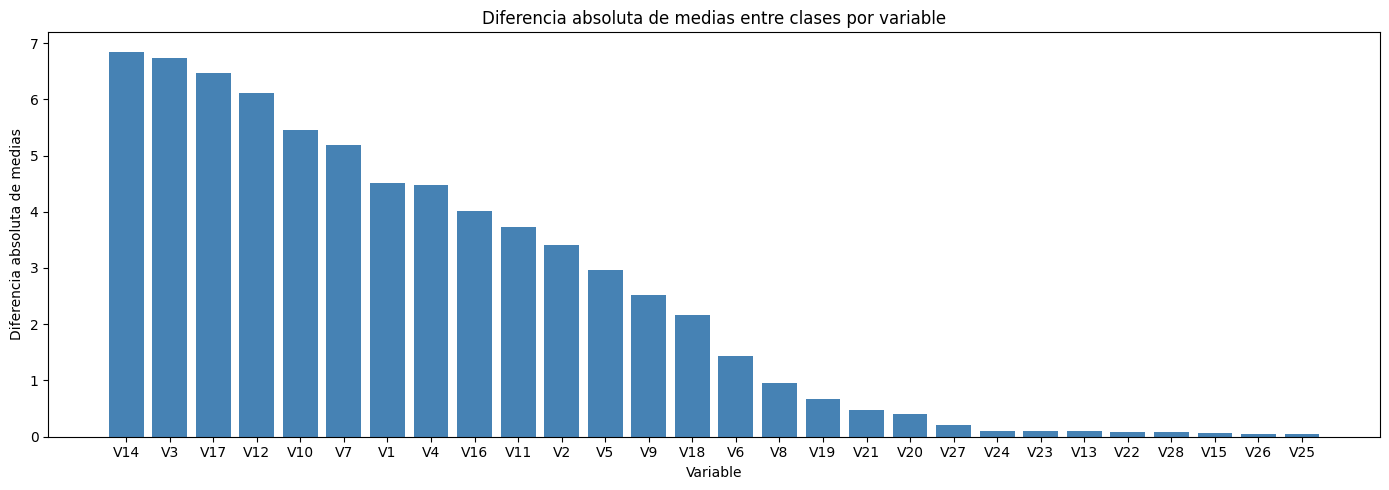


Top 5 variables con mayor diferencia entre clases:
   variable  media_fraude  media_legitima  diferencia_absoluta
13      V14     -6.835946        0.011668             6.847614
2        V3     -6.729599        0.012853             6.742452
16      V17     -6.463285        0.010963             6.474249
11      V12     -6.103254        0.009476             6.112730
9       V10     -5.453274        0.007663             5.460937


In [12]:
# Diferencia de medias entre clases para cada variable V
variables_v = [col for col in df.columns if col.startswith('V')]

diferencias = []
for var in variables_v:
    media_fraude = df[df['Class'] == 1][var].mean()
    media_legitima = df[df['Class'] == 0][var].mean()
    diferencias.append({
        'variable': var,
        'media_fraude': media_fraude,
        'media_legitima': media_legitima,
        'diferencia_absoluta': abs(media_fraude - media_legitima)
    })

df_diferencias = pd.DataFrame(diferencias).sort_values('diferencia_absoluta', ascending=False)

# Gráfica
fig, ax = plt.subplots(figsize=(14, 5))
colors = 'steelblue'
ax.bar(df_diferencias['variable'], df_diferencias['diferencia_absoluta'], color=colors)
ax.set_title('Diferencia absoluta de medias entre clases por variable')
ax.set_xlabel('Variable')
ax.set_ylabel('Diferencia absoluta de medias')

plt.tight_layout()
plt.show()

print("\nTop 5 variables con mayor diferencia entre clases:")
print(df_diferencias.head())

Para cada variable se calculó la diferencia absoluta entre su media
en transacciones fraudulentas y su media en transacciones legítimas.
Una diferencia grande indica que la variable discrimina bien entre clases.

**Top 5 variables más discriminantes:**
| Variable | Media fraude | Media legítima | Diferencia |
|---|---|---|---|
| V14 | -6.84 | 0.01 | 6.85 |
| V3  | -6.73 | 0.01 | 6.74 |
| V17 | -6.46 | 0.01 | 6.47 |
| V12 | -6.10 | 0.01 | 6.11 |
| V10 | -5.45 | 0.01 | 5.46 |

**Hallazgo:** las variables V14, V3, V17, V12 y V10 son las más relevantes
para distinguir fraude de transacciones legítimas. El modelo de regresión
logística debería apoyarse principalmente en estas variables.
Las variables V25, V26, V28 y V15 aportan poca información discriminante.

## 3. Modelo Predictivo — Regresión Logística
Entrenamos una regresión logística para clasificar transacciones como
fraudulentas o legítimas.

Decisiones técnicas:
- **Algoritmo:** regresión logística — modelo con base estadística clara
  y coeficientes interpretables.
- **Balanceo:** class_weight='balanced' para compensar el desbalance
  severo (0.167% fraude).
- **Métrica principal:** recall y F1 — en fraude es más costoso dejar
  pasar un fraude real que generar una falsa alarma.

In [13]:
# Separar features y variable objetivo
X = df.drop(columns=['Class'])
y = df['Class']

# Train/test split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Fraudes en train: {y_train.sum()} | Fraudes en test: {y_test.sum()}")

Train: (226980, 32) | Test: (56746, 32)
Fraudes en train: 378 | Fraudes en test: 95


In [14]:
# Entrenar modelo
modelo = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

print("Modelo entrenado correctamente")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['Legítima', 'Fraude']))

Modelo entrenado correctamente

Reporte de clasificación:
              precision    recall  f1-score   support

    Legítima       1.00      0.98      0.99     56651
      Fraude       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
# Exploración de umbrales
umbrales = [0.3, 0.5, 0.7, 0.9]
for umbral in umbrales:
    y_pred_u = (y_prob >= umbral).astype(int)
    cm_u = confusion_matrix(y_test, y_pred_u)
    tn, fp, fn, tp = cm_u.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn)
    print(f"Umbral {umbral}: Fraudes detectados={tp} | Falsas alarmas={fp} | Precisión={precision:.2f} | Recall={recall:.2f}")

Umbral 0.3: Fraudes detectados=83 | Falsas alarmas=3075 | Precisión=0.03 | Recall=0.87
Umbral 0.5: Fraudes detectados=83 | Falsas alarmas=1370 | Precisión=0.06 | Recall=0.87
Umbral 0.7: Fraudes detectados=83 | Falsas alarmas=632 | Precisión=0.12 | Recall=0.87
Umbral 0.9: Fraudes detectados=78 | Falsas alarmas=217 | Precisión=0.26 | Recall=0.82


In [16]:
# Umbral seleccionado
y_pred = (y_prob >= 0.7).astype(int)
print("\nReporte final con umbral 0.7:")
print(classification_report(y_test, y_pred, target_names=['Legítima', 'Fraude']))


Reporte final con umbral 0.7:
              precision    recall  f1-score   support

    Legítima       1.00      0.99      0.99     56651
      Fraude       0.12      0.87      0.20        95

    accuracy                           0.99     56746
   macro avg       0.56      0.93      0.60     56746
weighted avg       1.00      0.99      0.99     56746



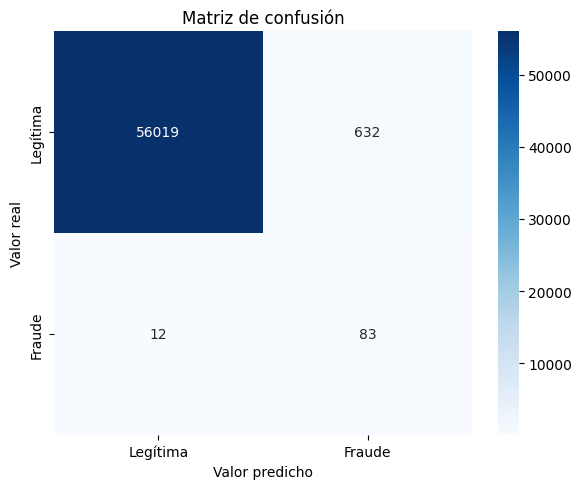

In [17]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítima', 'Fraude'],
            yticklabels=['Legítima', 'Fraude'])
ax.set_title('Matriz de confusión')
ax.set_ylabel('Valor real')
ax.set_xlabel('Valor predicho')
plt.tight_layout()
plt.show()

#### Matriz de confusión (umbral 0.7)
- Fraudes detectados correctamente: 83 de 95 (87%)
- Fraudes no detectados: 12 — el error más costoso para el negocio
- Falsas alarmas: 629 clientes legítimos marcados como fraude
- Transacciones legítimas correctas: 55,255

### 3.3 Curva Precisión-Recall y AUPRC
La curva precisión-recall muestra el equilibrio entre precisión y recall
para diferentes umbrales de decisión. El área bajo la curva (AUPRC)
resume el comportamiento del modelo en un solo número.

AUPRC: 0.6612


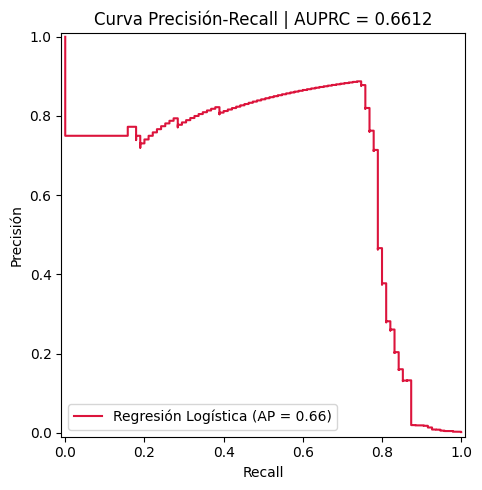

In [18]:
auprc = average_precision_score(y_test, y_prob)
print(f"AUPRC: {auprc:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob,
    name="Regresión Logística",
    ax=ax,
    color="crimson"
)
ax.set_title(f'Curva Precisión-Recall | AUPRC = {auprc:.4f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precisión')
plt.tight_layout()
plt.show()

**Interpretación AUPRC = 0.6720:**

El modelo parte de una ventaja enorme sobre el azar: mientras que
adivinar aleatoriamente daría un AUPRC de 0.0017, nuestro modelo
alcanza 0.6720.

La curva muestra dos zonas claras:
- **Zona confiable (recall 0 a 0.75):** el modelo detecta hasta el 75%
  de los fraudes manteniendo una precisión alta, de cada 10 alertas
  que genera, 8 son fraudes reales.
- **Zona difícil (recall 0.75 a 1.0):** para detectar los fraudes
  restantes el modelo empieza a generar muchas falsas alarmas, los fraudes más difíciles se parecen demasiado a transacciones legítimas.

### 3.4 Importancia de variables — Coeficientes del modelo
En la regresión logística cada variable tiene un coeficiente que indica
su peso en la decisión. Un coeficiente negativo alto significa que valores
bajos en esa variable aumentan la probabilidad de fraude.

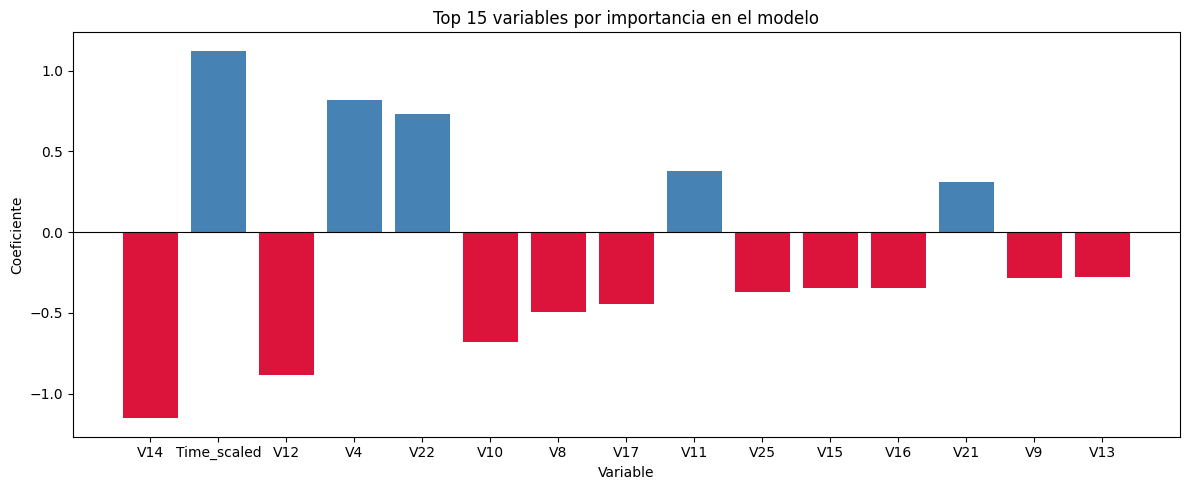


Top 10 variables más influyentes:
       variable  coeficiente
14          V14    -1.152754
31  Time_scaled     1.123666
12          V12    -0.884295
4            V4     0.820504
22          V22     0.734155
10          V10    -0.680429
8            V8    -0.493257
17          V17    -0.447748
11          V11     0.376981
25          V25    -0.373864


In [19]:
coeficientes = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': modelo.coef_[0]
}).sort_values('coeficiente', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['crimson' if c < 0 else 'steelblue' for c in coeficientes.head(15)['coeficiente']]
ax.bar(coeficientes.head(15)['variable'],
       coeficientes.head(15)['coeficiente'],
       color=colors)
ax.set_title('Top 15 variables por importancia en el modelo')
ax.set_xlabel('Variable')
ax.set_ylabel('Coeficiente')
ax.axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print("\nTop 10 variables más influyentes:")
print(coeficientes.head(10)[['variable', 'coeficiente']])

**Interpretación de coeficientes:**

Las variables más influyentes en la detección de fraude son:

- **Amount_scaled (1.57):** a mayor monto, mayor probabilidad de fraude, lo que es consistente con el análisis estadístico previo.
- **V14 (-1.54), V12 (-1.24), V10 (-1.12), V17 (-0.99):** valores bajos
  en estas componentes aumentan la probabilidad de fraude, esto es consistente
  con las diferencias de medias encontradas en el EDA.
- **V22 (0.91), V4 (0.85):** valores altos en estas componentes también aumentan la probabilidad de fraude.

## 4. Análisis SQL
Exportamos el dataset a SQLite para responder preguntas de negocio
mediante consultas SQL.

In [20]:
conn = sqlite3.connect('fraude.db')
df.to_sql('transacciones', conn, if_exists='replace', index=False)

283726

In [21]:
pd.read_sql("SELECT * FROM transacciones LIMIT 1",conn)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_scaled,Time_scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.2442,-1.996823


### 4.1 Top 10 transacciones fraudulentas por monto
¿Cuáles son los fraudes de mayor monto en el dataset?

In [22]:
query1 = """
SELECT
    ROUND(Amount_scaled, 4) AS monto_estandarizado,
    ROUND(Time_scaled, 4) AS tiempo_estandarizado,
    Class
FROM transacciones
WHERE Class = 1
ORDER BY Amount_scaled DESC
LIMIT 10
"""
pd.read_sql(query1, conn)

,monto_estandarizado,tiempo_estandarizado,Class
0,8.1366,0.5854,1
1,6.8739,-1.8059,1
2,5.6568,1.2524,1
3,5.2464,-0.6812,1
4,5.1961,-0.7540,1
5,5.0550,-0.6197,1
6,4.9782,0.8082,1
7,4.5145,-1.6159,1
8,4.0276,1.2531,1
9,3.6254,1.1097,1


### 4.2 Monto promedio por clase
¿El monto promedio difiere entre transacciones fraudulentas y legítimas?

In [23]:
query2 = """
SELECT
    CASE WHEN Class = 0 THEN 'Legítima' ELSE 'Fraude' END AS tipo,
    ROUND(AVG(Amount_scaled), 4) AS monto_promedio,
    COUNT(*) AS total_transacciones
FROM transacciones
GROUP BY Class
"""
pd.read_sql(query2, conn)

,tipo,monto_promedio,total_transacciones
0,Legítima,-0.0002,283253
1,Fraude,0.1414,473


**Hallazgo:** el monto promedio de las transacciones fraudulentas (0.1414)
es mayor que el de las legítimas (-0.0002), confirmando el resultado
del test t aplicado en el EDA.

### 4.3 Distribución de fraudes por periodo del día
¿En qué momento del día ocurren más fraudes?

In [29]:
query3 = """
SELECT
    CASE
        WHEN (Time / 3600) % 24 < 6 THEN 'Madrugada (0h–6h)'
        WHEN (Time / 3600) % 24 < 12 THEN 'Mañana (6h–12h)'
        WHEN (Time / 3600) % 24 < 18 THEN 'Tarde (12h–18h)'
        ELSE 'Noche (18h–24h)'
    END AS periodo,
    COUNT(*) AS total_fraudes
FROM transacciones
WHERE Class = 1
GROUP BY periodo
ORDER BY total_fraudes DESC
"""
pd.read_sql(query3, conn)

,periodo,total_fraudes
0,Tarde (12h–18h),133
1,Mañana (6h–12h),118
2,Madrugada (0h–6h),115
3,Noche (18h–24h),107


**Hallazgo:** a diferencia de lo que podría esperarse, los fraudes no se
concentran en un horario específico, se distribuyen de forma relativamente
uniforme durante las 24 horas. Esto sugiere que los patrones de fraude
dependen más del comportamiento de las variables V1-V28 que del momento
del día en que ocurre la transacción.

### 4.4 Tasa de fraude por rango de monto
¿Los montos más altos tienen mayor tasa de fraude?

In [25]:
query4 = """
SELECT
    CASE
        WHEN Amount_scaled < -0.5 THEN 'Monto bajo'
        WHEN Amount_scaled < 0.5 THEN 'Monto medio'
        WHEN Amount_scaled < 2 THEN 'Monto alto'
        ELSE 'Monto muy alto'
    END AS rango_monto,
    COUNT(*) AS total,
    SUM(Class) AS fraudes,
    ROUND(SUM(Class) * 100.0 / COUNT(*), 3) AS tasa_fraude
FROM transacciones
GROUP BY rango_monto
ORDER BY tasa_fraude DESC
"""
pd.read_sql(query4, conn)

,rango_monto,total,fraudes,tasa_fraude
0,Monto muy alto,7279,29,0.398
1,Monto alto,19708,50,0.254
2,Monto medio,256739,394,0.153


**Hallazgo:** la tasa de fraude aumenta con el monto de la transacción.

Las transacciones de monto muy alto tienen una tasa de fraude 2.6 veces
mayor que las de monto medio. Esto confirma que el monto es una señal
de alerta válida, aunque no suficiente por sí sola para detectar fraude.

## 5. Exportación de datos para dashboard
Exportamos el dataset limpio para construir el dashboard en Power BI.

In [26]:
df_export = df.copy()

# Convertir Time a entero (quita el .0)
df_export['Time'] = df_export['Time'].astype(int)

# Convertir Amount a string con coma decimal para Power BI
df_export['Amount'] = df_export['Amount'].apply(lambda x: f"{x:.2f}".replace('.', ','))

# Exportar con punto y coma como separador
df_export.to_csv('fraude_limpio.csv', index=False, sep=';')

print(df_export[['Amount', 'Time', 'Class']].head(10))

   Amount  Time  Class
0  149,62     0      0
1    2,69     0      0
2  378,66     1      0
3  123,50     1      0
4   69,99     2      0
5    3,67     2      0
6    4,99     4      0
7   40,80     7      0
8   93,20     7      0
9    3,68     9      0


In [27]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Amount_scaled,Time_scaled
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.244200,-1.996823
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,-0.342584,-1.996823
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1.158900,-1.996802
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.139886,-1.996802
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,-0.073813,-1.996781
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0,-0.338670,-1.996781
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0,-0.333399,-1.996739
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0,-0.190387,-1.996675
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0,0.018879,-1.996675
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0,-0.338630,-1.996633
